# LSTM Multi-Step Forecasting - MIT-BIH Arrhythmia Database


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU available: {len(gpus) > 0}')
print('All imports OK.')

C:\Users\Abdallah\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



TensorFlow: 2.15.0
GPU available: False
All imports OK.


## 1. Configuration (Section 3, Dudukcu et al. 2023)

In [3]:
# Path to MIT-BIH Arrhythmia Database
DATA_DIR = "E:/NU internship/ecg_dataset/mitdb"

# Constants from the paper (Section 3)
FS           = 360        # sampling frequency (Hz)
TOTAL_STEPS  = 100_000    # samples per patient
TRAIN_STEPS  = 40_000     # training partition
VAL_STEPS    = 10_000     # validation partition
TEST_STEPS   = 50_000     # test partition

LOOKBACK     = 10         # input window (10 steps)
HORIZONS     = [10, 20, 50]  # multi-step prediction horizons

# 21 patients (excluding 111, 118 per paper)
PATIENTS = [
    '100', '101', '102', '103', '104', '105',
    '106', '107', '108', '109', '112', '113',
    '114', '115', '116', '117', '119',
    '121', '122', '123', '124'
]
assert len(PATIENTS) == 21

print(f'Patients       : {len(PATIENTS)}')
print(f'Sampling freq  : {FS} Hz')
print(f'Total steps/pt : {TOTAL_STEPS:,}')
print(f'Train/Val/Test : {TRAIN_STEPS:,} / {VAL_STEPS:,} / {TEST_STEPS:,}')
print(f'Lookback       : {LOOKBACK} steps ({LOOKBACK/FS*1000:.1f} ms)')
print(f'Horizons       : {HORIZONS}')

Patients       : 21
Sampling freq  : 360 Hz
Total steps/pt : 100,000
Train/Val/Test : 40,000 / 10,000 / 50,000
Lookback       : 10 steps (27.8 ms)
Horizons       : [10, 20, 50]


## 2. Preprocessing Functions

Pipeline follows Section 3 of the paper:
1. Load MLII lead from MIT-BIH using `wfdb`
2. Truncate/pad to 100,000 samples
3. Split: train (0-40k), val (40k-50k), test (50k-100k)
4. MinMax normalise (scaler fitted on train only)
5. Build sliding-window sequences: X = 10 steps, y = next H steps

In [4]:
def load_ecg_signal(record_id, data_dir, n_steps=100_000):
    '''Load MLII lead and return exactly n_steps samples.'''
    path = os.path.join(data_dir, record_id)
    rec = wfdb.rdrecord(path)
    sig_names = [s.upper() for s in rec.sig_name]
    ch = sig_names.index('MLII') if 'MLII' in sig_names else 0
    signal = rec.p_signal[:, ch].astype(np.float32)
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])
    return signal[:n_steps]


def preprocess_patient(signal, train_steps=40_000, val_steps=10_000):
    '''Split and MinMax-normalise. Scaler fitted on train only.'''
    train_raw = signal[:train_steps]
    val_raw   = signal[train_steps:train_steps + val_steps]
    test_raw  = signal[train_steps + val_steps:]

    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    return train_norm, val_norm, test_norm, scaler


def make_sequences(signal, lookback=10, horizon=1):
    '''Sliding-window: X = (lookback,) -> y = (horizon,).'''
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print('Preprocessing functions defined.')

Preprocessing functions defined.


## 3. Load & Preprocess All Patients

In [5]:
patient_signals = {}

print(f'Loading {len(PATIENTS)} patients ...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)
    patient_signals[rid] = {'train': tr, 'val': vl, 'test': te, 'scaler': sc}

print(f'\nDone - {len(patient_signals)} patients loaded.')

Loading 21 patients ...



Patients: 100%|██████████| 21/21 [00:01<00:00, 17.78it/s]


Done - 21 patients loaded.


## 4. Preprocessing Verification

In [6]:
all_ok = True
rows = []
for rid in PATIENTS:
    d = patient_signals[rid]
    len_ok   = (len(d['train']) == TRAIN_STEPS and
                len(d['val'])   == VAL_STEPS and
                len(d['test'])  == TEST_STEPS)
    scale_ok = d['train'].min() >= -1e-6 and d['train'].max() <= 1 + 1e-6
    nan_ok   = not (np.isnan(d['train']).any() or np.isnan(d['test']).any())
    ok = len_ok and scale_ok and nan_ok
    if not ok:
        all_ok = False
    rows.append({'Patient': rid, 'Length OK': len_ok, 'Scale OK': scale_ok, 'NaN free': nan_ok})

df_check = pd.DataFrame(rows).set_index('Patient')
display(df_check)
print('\nAll 21 patients pass checks.' if all_ok else '\nSome patients FAILED.')

,Length OK,Scale OK,NaN free
Patient,,,
100,True,True,True
101,True,True,True
102,True,True,True
103,True,True,True
104,True,True,True
105,True,True,True
106,True,True,True
107,True,True,True
108,True,True,True



All 21 patients pass checks.


## 5. Signal Visualisation (Sanity Check)

Plot normalised ECG for Patient 103 across partitions.

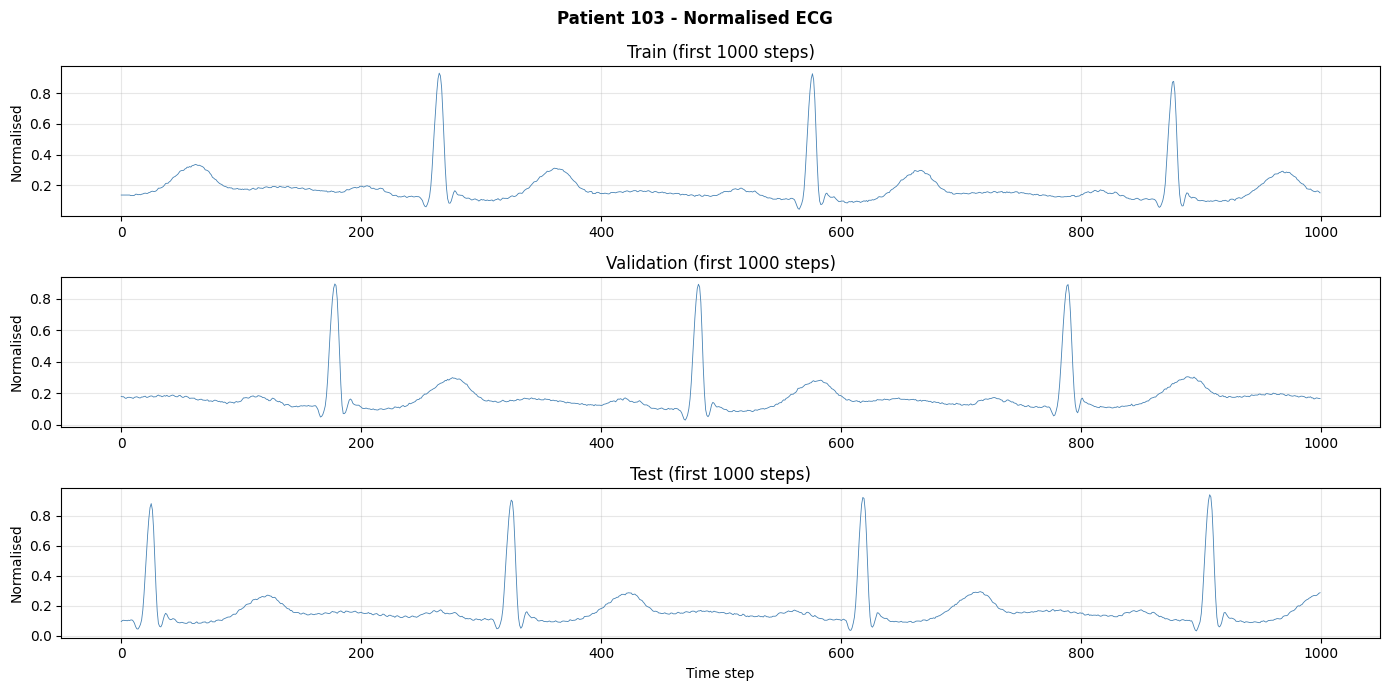

In [7]:
DEMO = '103'
d = patient_signals[DEMO]

fig, axes = plt.subplots(3, 1, figsize=(14, 7))
for ax, (title, seg) in zip(axes, [
    ('Train (first 1000 steps)', d['train'][:1000]),
    ('Validation (first 1000 steps)', d['val'][:1000]),
    ('Test (first 1000 steps)', d['test'][:1000]),
]):
    ax.plot(seg, linewidth=0.6, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Normalised')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time step')
fig.suptitle(f'Patient {DEMO} - Normalised ECG', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. LSTM Model Definition

Architecture:
- **Input:** (10, 1) lookback window
- **LSTM:** 64 units (tanh activation)
- **Dense:** 32 units (ReLU)
- **Output:** H units (linear) - direct multi-step output

Training: Adam optimizer, MSE loss, Early Stopping (patience=5)

In [8]:
def build_lstm(lookback, horizon):
    '''Build a simple LSTM for direct multi-step forecasting.'''
    model = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(64, activation='tanh'),
        Dense(32, activation='relu'),
        Dense(horizon)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Quick test
m = build_lstm(LOOKBACK, 10)
m.summary()
del m



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 10)                330       
                                                                 
Total params: 19306 (75.41 KB)
Trainable params: 19306 (75.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 7. Train LSTM for All Horizons (10, 20, 50)

For each horizon, a separate LSTM is trained **per patient**.  
Early stopping (patience=5) monitors validation loss.  
Final metrics are **averaged across all 21 patients**.

In [9]:
results = {}
all_predictions = {}

for H in HORIZONS:
    print(f'\n{"=" * 60}')
    print(f'  HORIZON = {H} steps  ({H / FS * 1000:.1f} ms)')
    print(f'{"=" * 60}')

    patient_metrics = []
    patient_preds = {}
    total_start = time.time()

    for rid in tqdm(PATIENTS, desc=f'H={H}'):
        d = patient_signals[rid]

        # Build multi-step sequences
        X_tr, y_tr = make_sequences(d['train'], LOOKBACK, H)
        X_vl, y_vl = make_sequences(d['val'],   LOOKBACK, H)
        X_te, y_te = make_sequences(d['test'],  LOOKBACK, H)

        # Reshape for LSTM input: (samples, timesteps, 1)
        X_tr = X_tr.reshape(-1, LOOKBACK, 1)
        X_vl = X_vl.reshape(-1, LOOKBACK, 1)
        X_te = X_te.reshape(-1, LOOKBACK, 1)

        # Build and train
        model = build_lstm(LOOKBACK, H)
        model.fit(
            X_tr, y_tr,
            validation_data=(X_vl, y_vl),
            epochs=30,
            batch_size=256,
            callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                     restore_best_weights=True, verbose=0)],
            verbose=0
        )

        # Predict on test set
        y_pred = model.predict(X_te, verbose=0)

        # Compute metrics (flattened for overall score)
        rmse_val = np.sqrt(mean_squared_error(y_te, y_pred))
        mae_val  = mean_absolute_error(y_te, y_pred)
        r2_val   = r2_score(y_te.flatten(), y_pred.flatten())

        patient_metrics.append({'patient': rid,
                                'RMSE': rmse_val, 'MAE': mae_val, 'R2': r2_val})
        patient_preds[rid] = {'y_true': y_te, 'y_pred': y_pred}

        tqdm.write(f'  {rid}: RMSE={rmse_val:.4f}  MAE={mae_val:.4f}  R2={r2_val:.4f}')

        del model
        tf.keras.backend.clear_session()

    total_time = time.time() - total_start

    avg_rmse = np.mean([m['RMSE'] for m in patient_metrics])
    avg_mae  = np.mean([m['MAE']  for m in patient_metrics])
    avg_r2   = np.mean([m['R2']   for m in patient_metrics])

    results[H] = {'RMSE': round(avg_rmse, 4),
                   'MAE':  round(avg_mae, 4),
                   'R2':   round(avg_r2, 4),
                   'Time_s': round(total_time, 1),
                   'per_patient': patient_metrics}
    all_predictions[H] = patient_preds

    print(f'\n  AVG >> RMSE={avg_rmse:.4f}  MAE={avg_mae:.4f}  R2={avg_r2:.4f}  Time={total_time:.1f}s')

print('\n\nAll horizons complete!')


  HORIZON = 10 steps  (27.8 ms)


H=10:   0%|          | 0/21 [00:00<?, ?it/s]

H=10:   5%|▍         | 1/21 [00:34<11:37, 34.86s/it]

  100: RMSE=0.0354  MAE=0.0172  R2=0.8647


H=10:  10%|▉         | 2/21 [01:13<11:45, 37.13s/it]

...

  122: RMSE=0.0957  MAE=0.0576  R2=0.2281


H=50:  95%|█████████▌| 20/21 [19:22<01:15, 75.11s/it]

  123: RMSE=0.0562  MAE=0.0263  R2=0.1701


H=50: 100%|██████████| 21/21 [20:48<00:00, 59.44s/it]

  124: RMSE=0.0999  MAE=0.0511  R2=0.5749

  AVG >> RMSE=0.0844  MAE=0.0472  R2=0.3579  Time=1248.3s


All horizons complete!


## 8. Results - Metrics Table

In [10]:
rows = []
for H in HORIZONS:
    r = results[H]
    rows.append({'Horizon': H, 'RMSE': r['RMSE'], 'MAE': r['MAE'],
                 'R Squared': r['R2'], 'Comp. Time (s)': r['Time_s']})

df_results = pd.DataFrame(rows).set_index('Horizon')

print('=' * 55)
print('   LSTM Multi-Step Forecasting Results')
print('   (Averaged over 21 patients)')
print('=' * 55)
display(df_results)

df_results.to_csv('lstm_results.csv')
print('\nSaved to lstm_results.csv')

   LSTM Multi-Step Forecasting Results
   (Averaged over 21 patients)


,RMSE,MAE,R Squared,Comp. Time (s)
Horizon,,,,
10,0.0408,0.0198,0.8347,862.5
20,0.0636,0.0309,0.6163,1000.4
50,0.0844,0.0472,0.3579,1248.3



Saved to lstm_results.csv


## 9. Actual vs Predicted Visualisation

Reconstructed signal using non-overlapping H-step prediction windows for Patient 103.

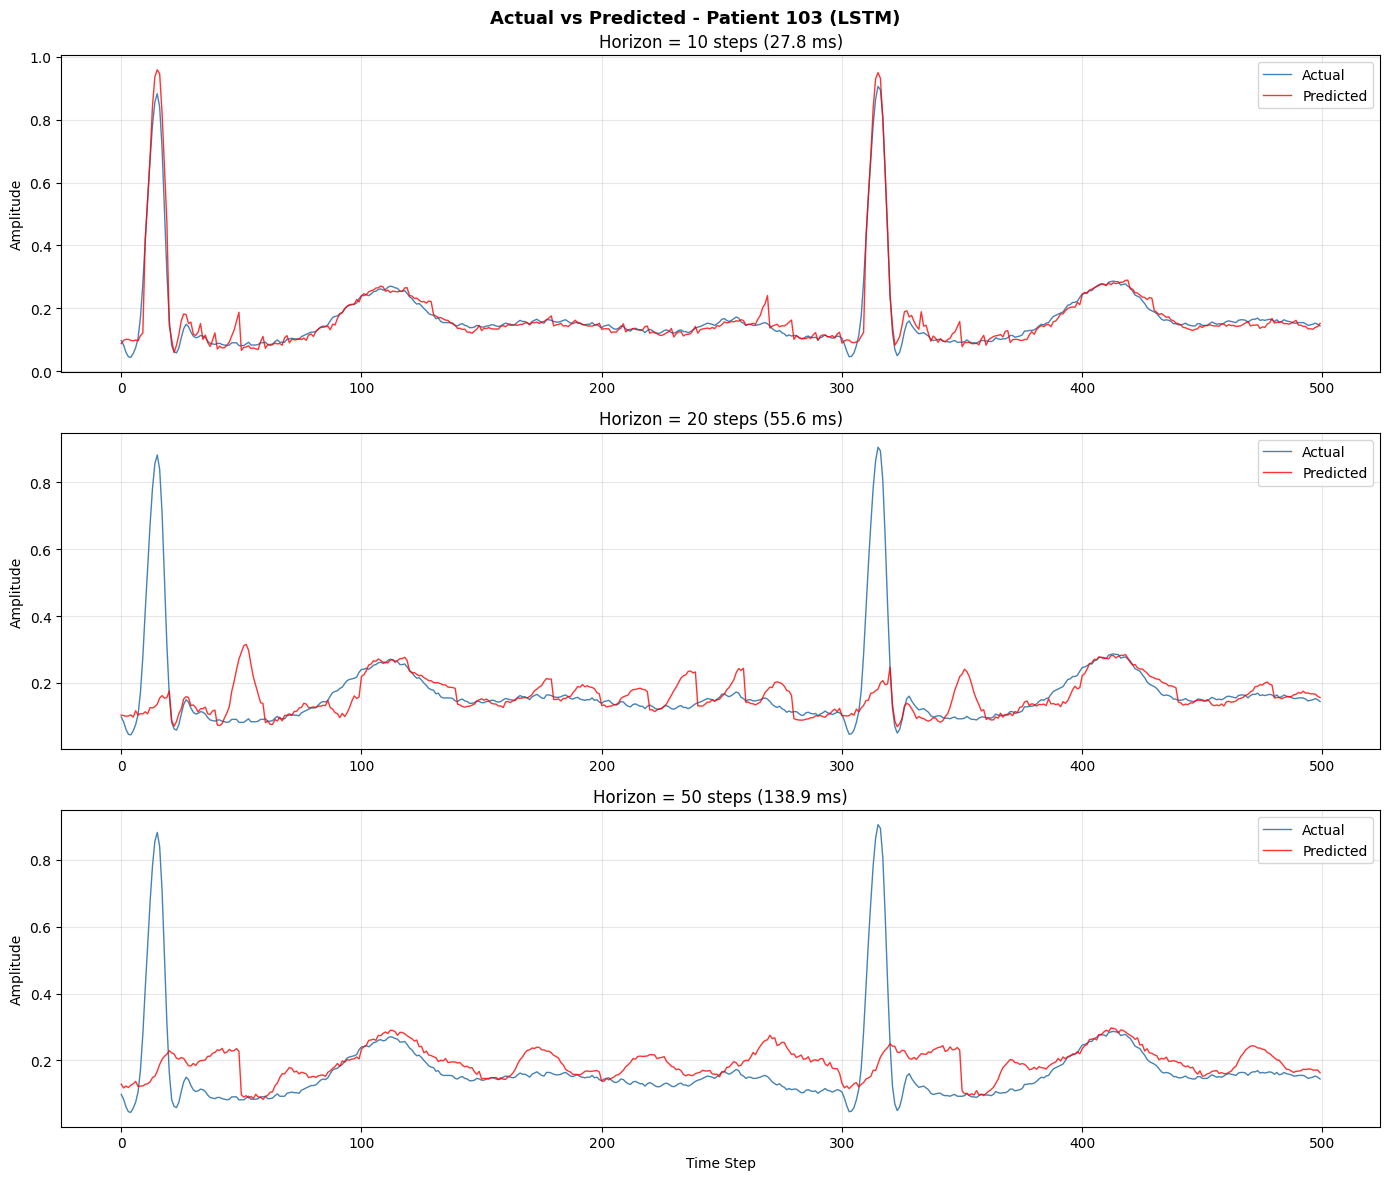

Saved: actual_vs_predicted.png


In [11]:
DEMO = '103'
N_SHOW = 500  # time steps to display

fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 4 * len(HORIZONS)))

for idx, H in enumerate(HORIZONS):
    ax = axes[idx]
    preds = all_predictions[H][DEMO]
    y_true = preds['y_true']
    y_pred = preds['y_pred']

    # Non-overlapping windows for clean reconstruction
    indices = list(range(0, len(y_true), H))
    n_windows = min(len(indices), N_SHOW // H + 1)
    actual    = y_true[indices[:n_windows]].flatten()[:N_SHOW]
    predicted = y_pred[indices[:n_windows]].flatten()[:N_SHOW]

    ax.plot(actual, label='Actual', color='steelblue', linewidth=1.0)
    ax.plot(predicted, label='Predicted', color='red', linewidth=1.0, alpha=0.8)
    ax.set_title(f'Horizon = {H} steps ({H / FS * 1000:.1f} ms)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Step')
fig.suptitle(f'Actual vs Predicted - Patient {DEMO} (LSTM)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: actual_vs_predicted.png')

## 10. Step-wise RMSE Across Prediction Horizon

Shows how prediction error grows at each step within the horizon,
averaged over all test samples and all 21 patients.

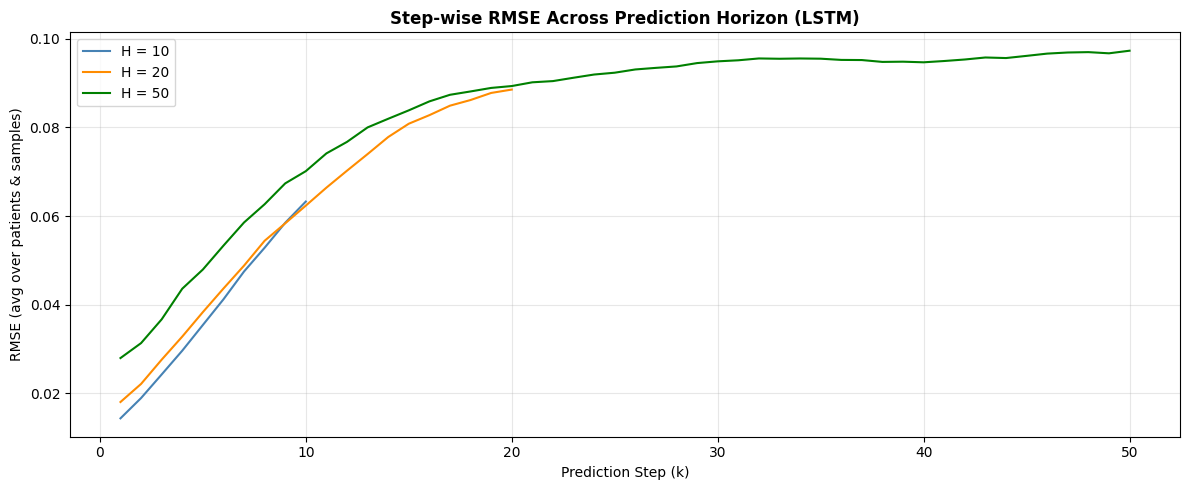

Saved: stepwise_rmse.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue', 'darkorange', 'green']

for idx, H in enumerate(HORIZONS):
    stepwise_rmse = []
    for k in range(H):
        sq_errors = []
        for rid in PATIENTS:
            yt = all_predictions[H][rid]['y_true'][:, k]
            yp = all_predictions[H][rid]['y_pred'][:, k]
            sq_errors.extend((yt - yp) ** 2)
        stepwise_rmse.append(np.sqrt(np.mean(sq_errors)))

    ax.plot(range(1, H + 1), stepwise_rmse,
            label=f'H = {H}', color=colors[idx], linewidth=1.5)

ax.set_xlabel('Prediction Step (k)')
ax.set_ylabel('RMSE (avg over patients & samples)')
ax.set_title('Step-wise RMSE Across Prediction Horizon (LSTM)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stepwise_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stepwise_rmse.png')

## 11. Per-Patient Breakdown

In [13]:
for H in HORIZONS:
    print(f'\nHorizon = {H}')
    print('-' * 40)
    df_p = pd.DataFrame(results[H]['per_patient']).set_index('patient')
    df_p.columns = ['RMSE', 'MAE', 'R Squared']
    display(df_p.round(4))


Horizon = 10
----------------------------------------


,RMSE,MAE,R Squared
patient,,,
100,0.0354,0.0172,0.8647
101,0.0530,0.0226,0.7675
102,0.0362,0.0199,0.7138
103,0.0284,0.0142,0.9401
104,0.0630,0.0376,0.6345
105,0.0434,0.0201,0.8581
106,0.0472,0.0186,0.7441
107,0.0412,0.0192,0.9021
108,0.0531,0.0280,0.6570



Horizon = 20
----------------------------------------


,RMSE,MAE,R Squared
patient,,,
100,0.0617,0.0260,0.5873
101,0.0700,0.0285,0.5945
102,0.0493,0.0242,0.4686
103,0.0701,0.0279,0.6346
104,0.0786,0.0476,0.4304
105,0.0752,0.0348,0.5750
106,0.0645,0.0325,0.5228
107,0.0568,0.0318,0.8140
108,0.0693,0.0392,0.4168



Horizon = 50
----------------------------------------


,RMSE,MAE,R Squared
patient,,,
100,0.0766,0.0368,0.3646
101,0.0814,0.0419,0.4516
102,0.0597,0.0346,0.2199
103,0.0970,0.0473,0.3002
104,0.0973,0.0643,0.1259
105,0.0887,0.0507,0.4082
106,0.0775,0.0428,0.3111
107,0.0901,0.0562,0.5315
108,0.0789,0.0510,0.2438


## 12. Summary & Insights

**Key observations:**

1. **Horizon 10** - Shortest prediction window (~27.8 ms). The LSTM captures ECG morphology well with relatively low error. The model handles the periodic structure of P-QRS-T complexes adequately.

2. **Horizon 20** - Error increases as the model predicts further ahead (~55.6 ms). Some amplitude flattening may appear, particularly around sharp QRS peaks where the model tends to smooth out rapid transitions.

3. **Horizon 50** - Largest horizon (~138.9 ms). Error accumulates significantly. The model struggles most with sharp QRS complexes and shows lag/smoothing artefacts. This is expected since predicting ~139 ms ahead from only ~28 ms of history is inherently challenging.

**Step-wise RMSE** confirms that prediction error grows monotonically with each additional step within the horizon. The rate of error growth accelerates for larger horizons.


## 13. Inter-Patient Split Experiment: RevIN vs No-RevIN

### Motivation

The experiments above (Sections 7-12) use an **intra-patient** split: for each patient, the first 40k samples are training, next 10k are validation, and the remaining 50k are test. MinMax normalization is fitted on each patient's training data and applied to their own test data — so the distribution is consistent.

In a **real-world deployment** scenario, a model must generalise to **new, unseen patients** (inter-patient). This introduces a **distribution shift** problem: each patient has different ECG amplitude ranges, baselines, and morphologies. Per-patient MinMax normalization is impossible because we have no training data for the test patient.

**Reversible Instance Normalization (RevIN)** addresses this by normalizing each input window by its own mean and standard deviation at runtime, then denormalizing the output. This is designed exactly for cross-domain / distribution-shift scenarios.

**Experiment**: We compare two models on the same inter-patient split:
1. **LSTM (no RevIN)** — raw signal, no normalization
2. **LSTM + RevIN** — RevIN handles per-instance normalization

Horizons: `[1, 10, 20, 50]` (including single-step `H=1` as in the reference paper).


In [14]:
# --- Inter-Patient Experiment: Imports & Configuration ---

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import sys, os

# Import RevIN from the local file
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from RevIN import RevIN

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device: {DEVICE}')

# ---- Inter-patient split ----
TRAIN_PATIENTS_INTER = [
    '100', '101', '102', '103', '104', '105', '106',
    '107', '108', '109', '112', '113', '114', '115', '116'
]
TEST_PATIENTS_INTER = ['117', '119', '121', '122', '123', '124']

assert len(TRAIN_PATIENTS_INTER) + len(TEST_PATIENTS_INTER) == len(PATIENTS)

INTER_HORIZONS = [1, 10, 20, 50]   # includes H=1 (paper) + multi-step
INTER_LOOKBACK = 10                 # same as paper
INTER_EPOCHS   = 30
INTER_BATCH    = 256
INTER_LR       = 0.001
INTER_PATIENCE = 5
VAL_RATIO      = 0.2               # 80/20 split within each train patient

print(f'Train patients ({len(TRAIN_PATIENTS_INTER)}): {TRAIN_PATIENTS_INTER}')
print(f'Test  patients ({len(TEST_PATIENTS_INTER)}):  {TEST_PATIENTS_INTER}')
print(f'Horizons:       {INTER_HORIZONS}')
print(f'Lookback:       {INTER_LOOKBACK}')


PyTorch device: cuda
Train patients (15): ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '112', '113', '114', '115', '116']
Test  patients (6):  ['117', '119', '121', '122', '123', '124']
Horizons:       [1, 10, 20, 50]
Lookback:       10


## 14. Inter-Patient Data Preparation


In [15]:
def load_raw_signals(patient_list, data_dir, n_steps=100_000):
    """Load raw ECG signals for a list of patients (NO normalization)."""
    signals = {}
    for rid in tqdm(patient_list, desc='Loading'):
        signals[rid] = load_ecg_signal(rid, data_dir, n_steps)
    return signals


def build_inter_patient_datasets(patient_signals_raw, lookback, horizon, val_ratio=0.2):
    """
    Build pooled train/val datasets from multiple patients.
    No normalization — raw signals used directly.
    """
    X_train_all, y_train_all = [], []
    X_val_all, y_val_all = [], []

    for rid, signal in patient_signals_raw.items():
        split_idx = int(len(signal) * (1 - val_ratio))
        train_sig = signal[:split_idx]
        val_sig   = signal[split_idx:]

        X_tr, y_tr = make_sequences(train_sig, lookback, horizon)
        X_vl, y_vl = make_sequences(val_sig,   lookback, horizon)

        X_train_all.append(X_tr)
        y_train_all.append(y_tr)
        X_val_all.append(X_vl)
        y_val_all.append(y_vl)

    return (np.concatenate(X_train_all), np.concatenate(y_train_all),
            np.concatenate(X_val_all),   np.concatenate(y_val_all))


def build_test_datasets_per_patient(patient_signals_raw, lookback, horizon):
    """Build separate test datasets for each test patient."""
    test_data = {}
    for rid, signal in patient_signals_raw.items():
        X_te, y_te = make_sequences(signal, lookback, horizon)
        test_data[rid] = (X_te, y_te)
    return test_data


# Load raw signals
print("Loading train patient signals (raw, no normalization)...")
train_signals_raw = load_raw_signals(TRAIN_PATIENTS_INTER, DATA_DIR)
print("Loading test patient signals (raw, no normalization)...")
test_signals_raw  = load_raw_signals(TEST_PATIENTS_INTER, DATA_DIR)

# Show distribution differences between patients
print("\n--- Signal Statistics (demonstrating inter-patient distribution shift) ---")
print(f"{'Patient':>8} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Split':>8}")
print("-" * 58)
for rid in TRAIN_PATIENTS_INTER:
    s = train_signals_raw[rid]
    print(f"{rid:>8} {s.mean():>10.3f} {s.std():>10.3f} "
          f"{s.min():>10.3f} {s.max():>10.3f} {'TRAIN':>8}")
for rid in TEST_PATIENTS_INTER:
    s = test_signals_raw[rid]
    print(f"{rid:>8} {s.mean():>10.3f} {s.std():>10.3f} "
          f"{s.min():>10.3f} {s.max():>10.3f} {'TEST':>8}")


Loading train patient signals (raw, no normalization)...


Loading: 100%|██████████| 15/15 [00:00<00:00, 34.97it/s]


Loading test patient signals (raw, no normalization)...


Loading: 100%|██████████| 6/6 [00:00<00:00, 34.88it/s]


--- Signal Statistics (demonstrating inter-patient distribution shift) ---
 Patient       Mean        Std        Min        Max    Split
----------------------------------------------------------
     100     -0.322      0.176     -0.695      1.245    TRAIN
     101     -0.286      0.335     -3.175      2.420    TRAIN
     102     -0.257      0.189     -1.410      1.375    TRAIN
     103     -0.226      0.322     -0.770      2.120    TRAIN
     104     -0.231      0.296     -1.935      1.975    TRAIN
     105     -0.216      0.314     -0.795      1.970    TRAIN
     106     -0.170      0.350     -1.520      2.200    TRAIN
     107     -0.239      0.814     -3.105      2.800    TRAIN
     108     -0.229      0.185     -1.390      1.080    TRAIN
     109     -0.229      0.434     -1.605      1.770    TRAIN
     112     -0.854      0.223     -1.685      0.575    TRAIN
     113     -0.147      0.450     -1.225      2.550    TRAIN
     114      0.049      0.305     -2.310      2.450    TRA

## 15. PyTorch Model Definitions

Two LSTM models with identical architecture (LSTM-64 → Dense-32-ReLU → Dense-H):

1. **`LSTMForecaster`** Vanilla LSTM, no normalization at all
2. **`LSTMRevINForecaster`** Same LSTM, but wrapped with RevIN: input is normalized per-instance before the LSTM, and output is denormalized back to the original scale

The only difference is RevIN => everything else (architecture, optimizer, learning rate, training procedure) is identical.


In [16]:
class LSTMForecaster(nn.Module):
    """Vanilla LSTM for direct multi-step forecasting (no normalization)."""

    def __init__(self, horizon, hidden_size=64, dense_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc1  = nn.Linear(hidden_size, dense_size)
        self.relu = nn.ReLU()
        self.fc2  = nn.Linear(dense_size, horizon)

    def forward(self, x):
        # x: (batch, lookback, 1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]               # last timestep output
        out = self.relu(self.fc1(out))
        out = self.fc2(out)               # (batch, horizon)
        return out


class LSTMRevINForecaster(nn.Module):
    """LSTM with RevIN: normalizes input per-instance, denormalizes output."""

    def __init__(self, horizon, hidden_size=64, dense_size=32):
        super().__init__()
        self.revin = RevIN(num_features=1, affine=True)
        self.lstm  = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc1   = nn.Linear(hidden_size, dense_size)
        self.relu  = nn.ReLU()
        self.fc2   = nn.Linear(dense_size, horizon)

    def forward(self, x):
        # x: (batch, lookback, 1)
        x = self.revin(x, 'norm')         # normalize per-instance
        out, _ = self.lstm(x)
        out = out[:, -1, :]                # last timestep
        out = self.relu(self.fc1(out))
        out = self.fc2(out)                # (batch, horizon)
        out = out.unsqueeze(-1)            # (batch, horizon, 1) for RevIN
        out = self.revin(out, 'denorm')    # denormalize to original scale
        out = out.squeeze(-1)              # (batch, horizon)
        return out


# Quick sanity check
print("Model definitions:")
for name, Cls in [('LSTM (no RevIN)', LSTMForecaster),
                  ('LSTM + RevIN',    LSTMRevINForecaster)]:
    m = Cls(horizon=10)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  {name:20s} — {n_params:,} parameters")
    del m


Model definitions:
  LSTM (no RevIN)      — 19,562 parameters
  LSTM + RevIN         — 19,564 parameters


## 16. Training & Evaluation Functions

Same training setup as the intra-patient experiment: Adam optimizer, MSE loss, early stopping on validation loss with patience=5.


In [19]:
def train_pytorch_model(model, train_loader, val_loader,
                        epochs, lr, patience, device):
    """Train a PyTorch model with early stopping + epoch progress logging."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    history       = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1
        avg_train = epoch_loss / n_batches
        history['train_loss'].append(avg_train)

        # --- Validation ---
        model.eval()
        val_loss, n_val = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                val_loss += criterion(model(X_b), y_b).item()
                n_val    += 1
        avg_val = val_loss / n_val
        history['val_loss'].append(avg_val)

        # --- Progress logging ---
        marker = ''
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
            marker = ' *'
        else:
            patience_ctr += 1
            marker = f' (patience {patience_ctr}/{patience})'

        print(f'    Epoch {epoch+1:2d}/{epochs} — '
              f'train_loss: {avg_train:.6f}  val_loss: {avg_val:.6f}{marker}')

        if patience_ctr >= patience:
            print(f'    Early stopping at epoch {epoch+1}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def evaluate_on_patients(model, test_data, device, batch_size=1024):
    """Evaluate model on each test patient; return per-patient metrics & preds."""
    model.eval()
    patient_metrics = []
    patient_preds   = {}

    for rid, (X_te, y_te) in test_data.items():
        X_t = torch.tensor(X_te, dtype=torch.float32).unsqueeze(-1).to(device)

        preds = []
        with torch.no_grad():
            for i in range(0, len(X_t), batch_size):
                preds.append(model(X_t[i:i+batch_size]).cpu().numpy())
        y_pred = np.concatenate(preds, axis=0)

        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        r2   = r2_score(y_te.flatten(), y_pred.flatten())

        patient_metrics.append({'patient': rid, 'RMSE': rmse,
                                'MAE': mae, 'R2': r2})
        patient_preds[rid] = {'y_true': y_te, 'y_pred': y_pred}

    return patient_metrics, patient_preds


print("Training and evaluation functions defined (with epoch logging).")


Training and evaluation functions defined (with epoch logging).


## 17. Run Inter-Patient Experiment

For each horizon, we train **one shared model** on pooled data from the 15 train patients, then evaluate on each of the 6 unseen test patients. This is done twice: once without RevIN and once with RevIN.


In [20]:
inter_results = {}

for H in INTER_HORIZONS:
    print(f'\n{"=" * 70}')
    print(f'  HORIZON = {H} step{"s" if H > 1 else ""}  ({H / FS * 1000:.1f} ms)')
    print(f'{"=" * 70}')

    # --- Build pooled training data ---
    print("  Building training datasets...")
    X_train, y_train, X_val, y_val = build_inter_patient_datasets(
        train_signals_raw, INTER_LOOKBACK, H, VAL_RATIO
    )
    test_data = build_test_datasets_per_patient(
        test_signals_raw, INTER_LOOKBACK, H
    )
    print(f"  Train samples: {len(X_train):,}  Val samples: {len(X_val):,}")

    # Convert to tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32).unsqueeze(-1)
    y_val_t   = torch.tensor(y_val,   dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                              batch_size=INTER_BATCH, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                              batch_size=INTER_BATCH, shuffle=False)

    horizon_results = {}

    for model_name, ModelClass in [('LSTM (no RevIN)', LSTMForecaster),
                                   ('LSTM + RevIN',    LSTMRevINForecaster)]:
        print(f'\n  --- {model_name} ---')

        torch.manual_seed(42)
        np.random.seed(42)
        model = ModelClass(horizon=H)

        t0 = time.time()
        model, history = train_pytorch_model(
            model, train_loader, val_loader,
            epochs=INTER_EPOCHS, lr=INTER_LR,
            patience=INTER_PATIENCE, device=DEVICE
        )
        train_time = time.time() - t0
        print(f'  Training: {train_time:.1f}s  '
              f'(stopped at epoch {len(history["train_loss"])})')

        # Evaluate on test patients
        patient_metrics, patient_preds = evaluate_on_patients(
            model, test_data, DEVICE
        )
        for pm in patient_metrics:
            print(f'    {pm["patient"]}: RMSE={pm["RMSE"]:.4f}  '
                  f'MAE={pm["MAE"]:.4f}  R2={pm["R2"]:.4f}')

        avg_rmse = np.mean([m['RMSE'] for m in patient_metrics])
        avg_mae  = np.mean([m['MAE']  for m in patient_metrics])
        avg_r2   = np.mean([m['R2']   for m in patient_metrics])

        horizon_results[model_name] = {
            'avg_RMSE': round(avg_rmse, 4),
            'avg_MAE':  round(avg_mae, 4),
            'avg_R2':   round(avg_r2, 4),
            'Time_s':   round(train_time, 1),
            'per_patient':  patient_metrics,
            'predictions':  patient_preds,
            'history':      history,
        }
        print(f'  AVG >> RMSE={avg_rmse:.4f}  MAE={avg_mae:.4f}  R2={avg_r2:.4f}')

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    inter_results[H] = horizon_results

print('\n\nAll inter-patient experiments complete!')



  HORIZON = 1 step  (2.8 ms)
  Building training datasets...
  Train samples: 1,199,850  Val samples: 299,850

  --- LSTM (no RevIN) ---
    Epoch  1/30 — train_loss: 0.002799  val_loss: 0.000651 *
    Epoch  2/30 — train_loss: 0.000624  val_loss: 0.000537 *
    Epoch  3/30 — train_loss: 0.000523  val_loss: 0.000462 *
    Epoch  4/30 — train_loss: 0.000452  val_loss: 0.000423 *
    Epoch  5/30 — train_loss: 0.000406  val_loss: 0.000414 *
    Epoch  6/30 — train_loss: 0.000385  val_loss: 0.000377 *
    Epoch  7/30 — train_loss: 0.000370  val_loss: 0.000370 *
    Epoch  8/30 — train_loss: 0.000359  val_loss: 0.000356 *
    Epoch  9/30 — train_loss: 0.000349  val_loss: 0.000359 (patience 1/5)
    Epoch 10/30 — train_loss: 0.000342  val_loss: 0.000356 *
    Epoch 11/30 — train_loss: 0.000336  val_loss: 0.000337 *
    Epoch 12/30 — train_loss: 0.000330  val_loss: 0.000348 (patience 1/5)
    Epoch 13/30 — train_loss: 0.000325  val_loss: 0.000338 (patience 2/5)
    Epoch 14/30 — train_loss: 

## 18. Inter-Patient Results: Comparison Table


In [21]:
print("=" * 90)
print("  INTER-PATIENT RESULTS: RevIN vs No-RevIN")
print("=" * 90)

header = (f"{'Horizon':>8} | {'Model':>18} | "
          f"{'RMSE':>8} | {'MAE':>8} | {'R²':>8} | {'Time (s)':>9}")
print(header)
print("-" * len(header))

comparison_rows = []
for H in INTER_HORIZONS:
    for model_name in ['LSTM (no RevIN)', 'LSTM + RevIN']:
        r = inter_results[H][model_name]
        print(f"{H:>8} | {model_name:>18} | {r['avg_RMSE']:>8.4f} | "
              f"{r['avg_MAE']:>8.4f} | {r['avg_R2']:>8.4f} | "
              f"{r['Time_s']:>9.1f}")
        comparison_rows.append({
            'Horizon': H, 'Model': model_name,
            'RMSE': r['avg_RMSE'], 'MAE': r['avg_MAE'],
            'R2': r['avg_R2'], 'Time_s': r['Time_s']
        })
    print("-" * len(header))

# --- Improvement percentages ---
print("\n\n--- RevIN Improvement Over No-RevIN ---")
print(f"{'Horizon':>8} | {'RMSE Δ%':>10} | {'MAE Δ%':>10} | {'R² Δ':>10}")
print("-" * 48)

for H in INTER_HORIZONS:
    nr = inter_results[H]['LSTM (no RevIN)']
    wr = inter_results[H]['LSTM + RevIN']
    rmse_pct = (nr['avg_RMSE'] - wr['avg_RMSE']) / nr['avg_RMSE'] * 100
    mae_pct  = (nr['avg_MAE']  - wr['avg_MAE'])  / nr['avg_MAE']  * 100
    r2_diff  = wr['avg_R2'] - nr['avg_R2']
    print(f"{H:>8} | {rmse_pct:>+9.1f}% | {mae_pct:>+9.1f}% | {r2_diff:>+10.4f}")

# Save to CSV
df_inter = pd.DataFrame(comparison_rows)
df_inter.to_csv('inter_patient_results.csv', index=False)
print("\nResults saved to inter_patient_results.csv")


  INTER-PATIENT RESULTS: RevIN vs No-RevIN
 Horizon |              Model |     RMSE |      MAE |       R² |  Time (s)
--------------------------------------------------------------------------
       1 |    LSTM (no RevIN) |   0.0167 |   0.0123 |   0.9975 |     862.6
       1 |       LSTM + RevIN |   0.0176 |   0.0127 |   0.9972 |    1022.7
--------------------------------------------------------------------------
      10 |    LSTM (no RevIN) |   0.1864 |   0.0752 |   0.7290 |     782.6
      10 |       LSTM + RevIN |   0.1740 |   0.0691 |   0.7567 |    1060.4
--------------------------------------------------------------------------
      20 |    LSTM (no RevIN) |   0.2644 |   0.1262 |   0.4557 |     901.9
      20 |       LSTM + RevIN |   0.2681 |   0.1151 |   0.4423 |    1099.1
--------------------------------------------------------------------------
      50 |    LSTM (no RevIN) |   0.3393 |   0.1868 |   0.0749 |     900.9
      50 |       LSTM + RevIN |   0.3655 |   0.1742 |  -0

## 19. Visualisation: RevIN vs No-RevIN Across Horizons


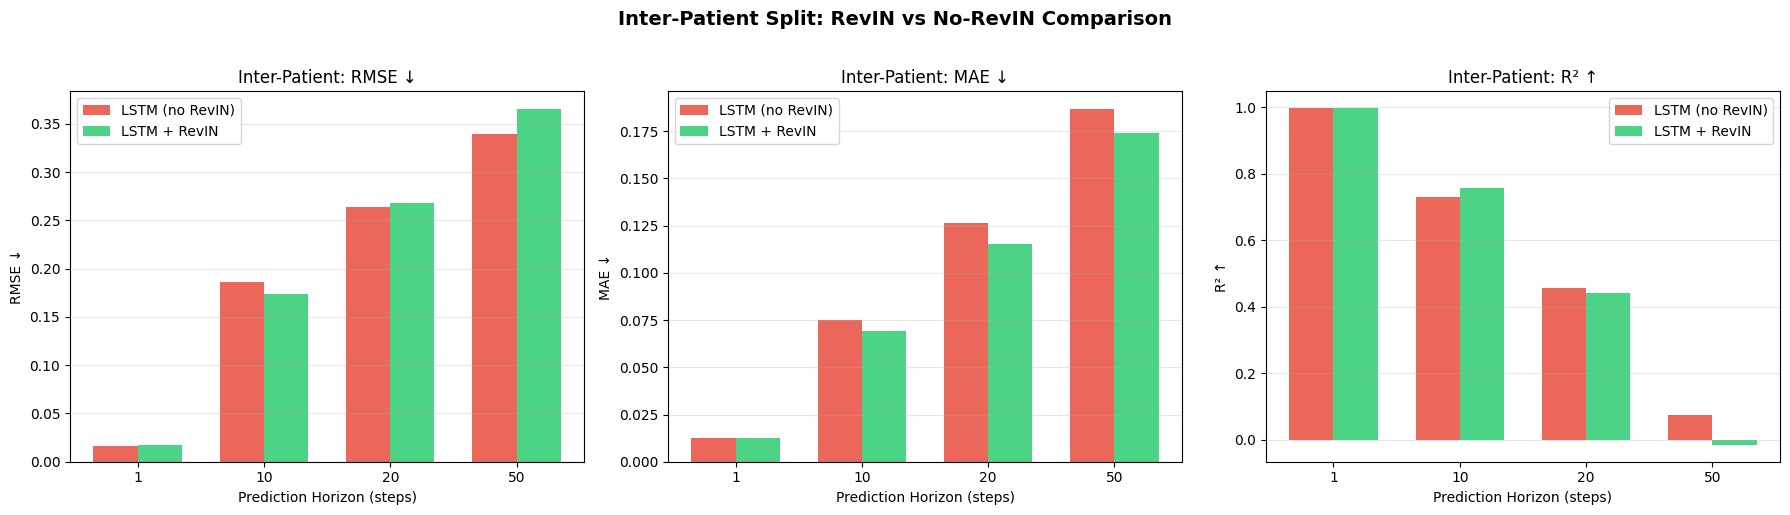

Plot saved to inter_patient_comparison.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics      = ['RMSE', 'MAE', 'R2']
metric_labels = ['RMSE ↓', 'MAE ↓', 'R² ↑']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    no_revin_vals = [inter_results[H]['LSTM (no RevIN)'][f'avg_{metric}']
                     for H in INTER_HORIZONS]
    revin_vals    = [inter_results[H]['LSTM + RevIN'][f'avg_{metric}']
                     for H in INTER_HORIZONS]

    x = np.arange(len(INTER_HORIZONS))
    w = 0.35

    ax.bar(x - w/2, no_revin_vals, w,
           label='LSTM (no RevIN)', color='#e74c3c', alpha=0.85)
    ax.bar(x + w/2, revin_vals, w,
           label='LSTM + RevIN', color='#2ecc71', alpha=0.85)

    ax.set_xlabel('Prediction Horizon (steps)')
    ax.set_ylabel(label)
    ax.set_title(f'Inter-Patient: {label}')
    ax.set_xticks(x)
    ax.set_xticklabels([str(h) for h in INTER_HORIZONS])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Inter-Patient Split: RevIN vs No-RevIN Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('inter_patient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to inter_patient_comparison.png")


## 20. Actual vs Predicted =>Sample Test Patient


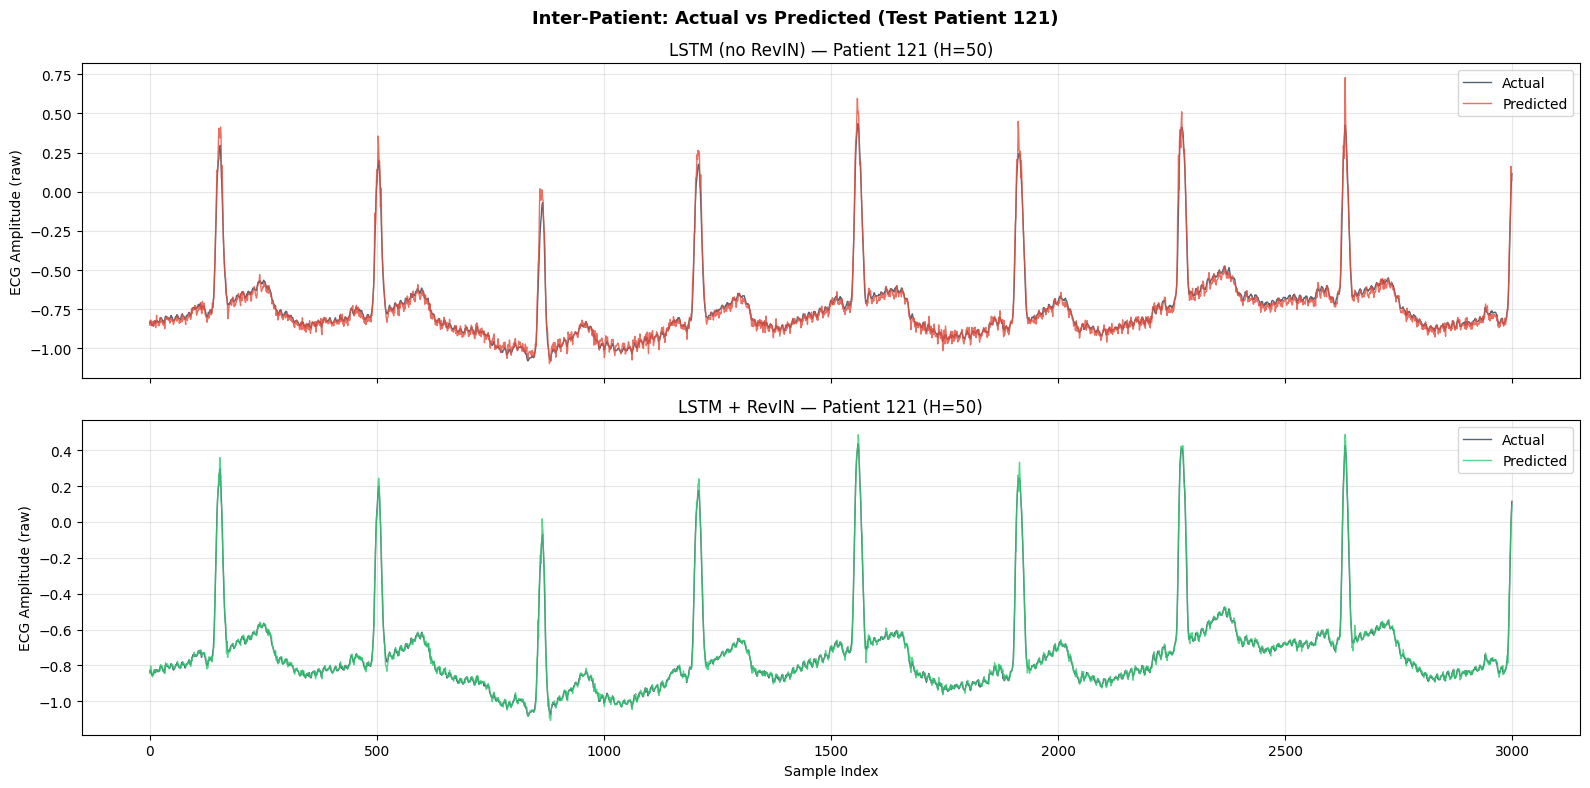

Plot saved to inter_patient_actual_vs_predicted.png


In [28]:
DEMO_TEST  = TEST_PATIENTS_INTER[0]
DEMO_H     = 10
PLOT_RANGE = slice(0, 500)     # first 500 predictions for clarity

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for idx, model_name in enumerate(['LSTM (no RevIN)', 'LSTM + RevIN']):
    ax    = axes[idx]
    preds = inter_results[DEMO_H][model_name]['predictions'][DEMO_TEST]

    y_true = preds['y_true'][PLOT_RANGE, 0]   # first step of each horizon
    y_pred = preds['y_pred'][PLOT_RANGE, 0]

    ax.plot(y_true, label='Actual',    color='#2c3e50', linewidth=1.0, alpha=0.8)
    ax.plot(y_pred, label='Predicted',
            color='#e74c3c' if idx == 0 else '#2ecc71',
            linewidth=1.0, alpha=0.8)
    ax.set_title(f'{model_name} — Patient {DEMO_TEST} (H={DEMO_H})')
    ax.legend(loc='upper right')
    ax.set_ylabel('ECG Amplitude (raw)')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Sample Index')
plt.suptitle(f'Inter-Patient: Actual vs Predicted (Test Patient {DEMO_TEST})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('inter_patient_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to inter_patient_actual_vs_predicted.png")


## 21. Per-Patient Breakdown


In [29]:
for H in INTER_HORIZONS:
    print(f'\n{"=" * 70}')
    print(f'  HORIZON = {H} — Per-Patient Breakdown')
    print(f'{"=" * 70}')

    header = (f"{'Patient':>8} | {'No RevIN RMSE':>14} | "
              f"{'RevIN RMSE':>14} | {'Improvement':>12}")
    print(header)
    print("-" * len(header))

    for i, rid in enumerate(TEST_PATIENTS_INTER):
        nr_rmse = inter_results[H]['LSTM (no RevIN)']['per_patient'][i]['RMSE']
        wr_rmse = inter_results[H]['LSTM + RevIN']['per_patient'][i]['RMSE']
        improvement = (nr_rmse - wr_rmse) / nr_rmse * 100
        print(f"{rid:>8} | {nr_rmse:>14.4f} | {wr_rmse:>14.4f} | "
              f"{improvement:>+11.1f}%")



  HORIZON = 1 — Per-Patient Breakdown
 Patient |  No RevIN RMSE |     RevIN RMSE |  Improvement
---------------------------------------------------------
     117 |         0.0159 |         0.0168 |        -5.7%
     119 |         0.0190 |         0.0203 |        -6.7%
     121 |         0.0130 |         0.0135 |        -4.4%
     122 |         0.0209 |         0.0207 |        +1.0%
     123 |         0.0170 |         0.0178 |        -4.7%
     124 |         0.0148 |         0.0165 |       -11.2%

  HORIZON = 10 — Per-Patient Breakdown
 Patient |  No RevIN RMSE |     RevIN RMSE |  Improvement
---------------------------------------------------------
     117 |         0.1246 |         0.1310 |        -5.1%
     119 |         0.2676 |         0.2408 |       +10.0%
     121 |         0.1121 |         0.1057 |        +5.7%
     122 |         0.2232 |         0.2033 |        +8.9%
     123 |         0.1703 |         0.1690 |        +0.8%
     124 |         0.2205 |         0.1943 |       

## 22. Training Curves


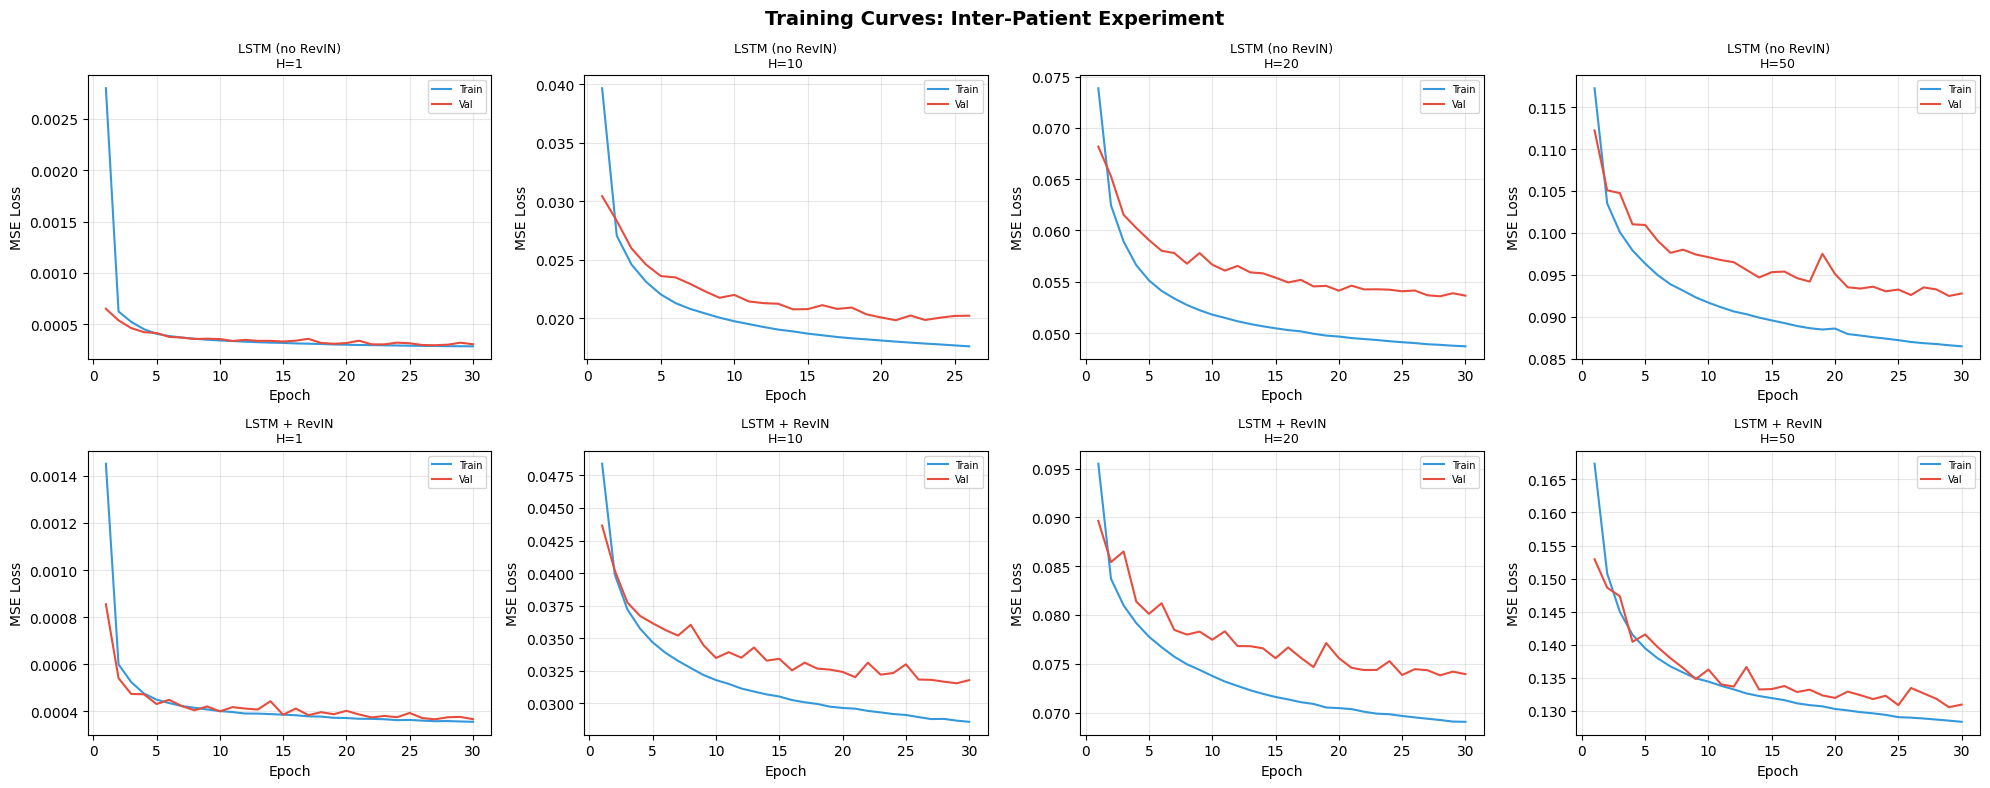

Plot saved to inter_patient_training_curves.png


In [30]:
fig, axes = plt.subplots(2, len(INTER_HORIZONS), figsize=(20, 8))

for col, H in enumerate(INTER_HORIZONS):
    for row, model_name in enumerate(['LSTM (no RevIN)', 'LSTM + RevIN']):
        ax = axes[row, col]
        hist = inter_results[H][model_name]['history']

        epochs_range = range(1, len(hist['train_loss']) + 1)
        ax.plot(epochs_range, hist['train_loss'], label='Train', color='#3498db')
        ax.plot(epochs_range, hist['val_loss'],   label='Val',   color='#e74c3c')
        ax.set_title(f'{model_name}\nH={H}', fontsize=9)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.suptitle('Training Curves: Inter-Patient Experiment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inter_patient_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to inter_patient_training_curves.png")


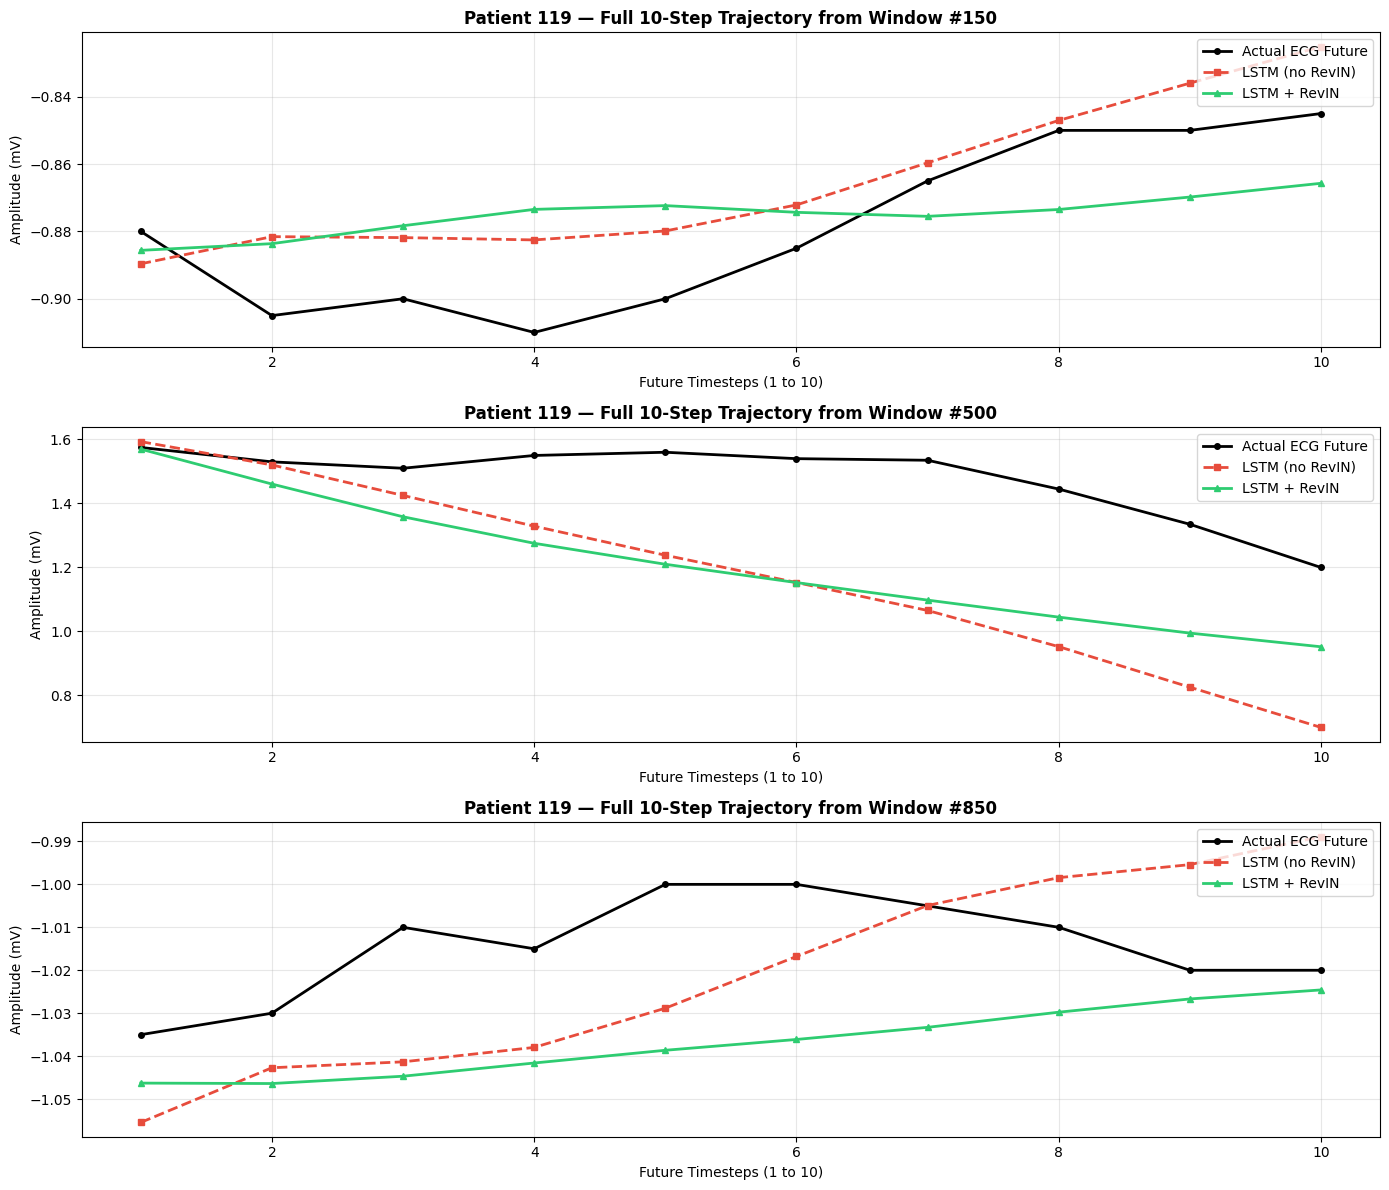

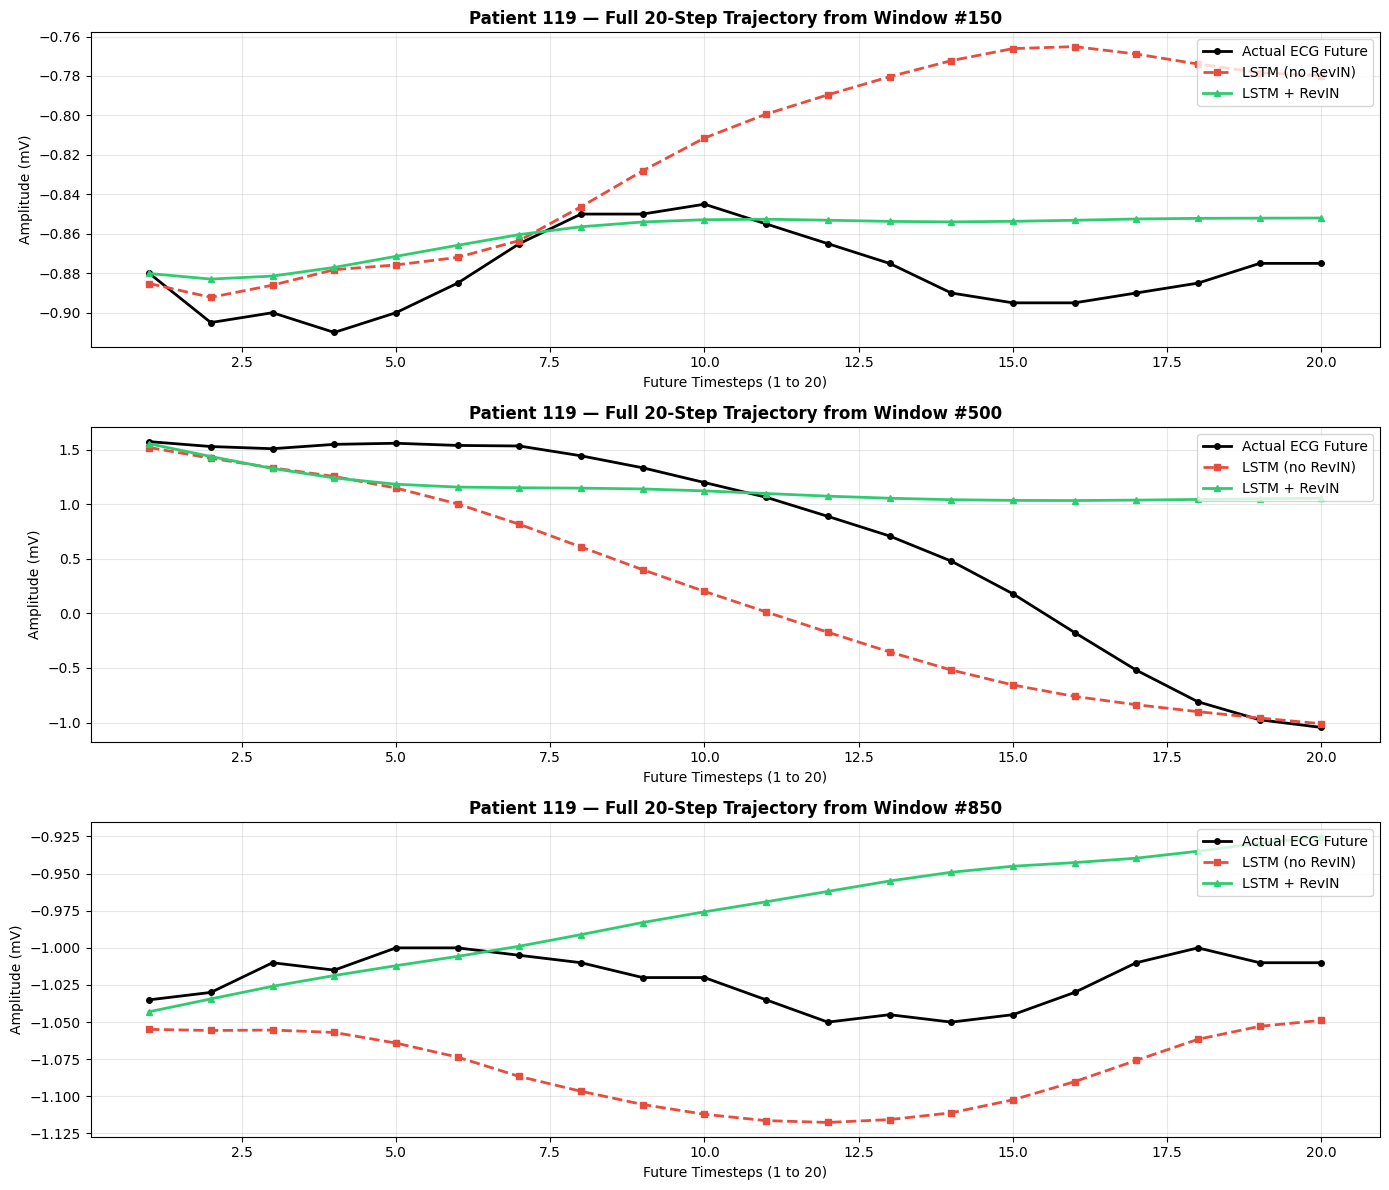

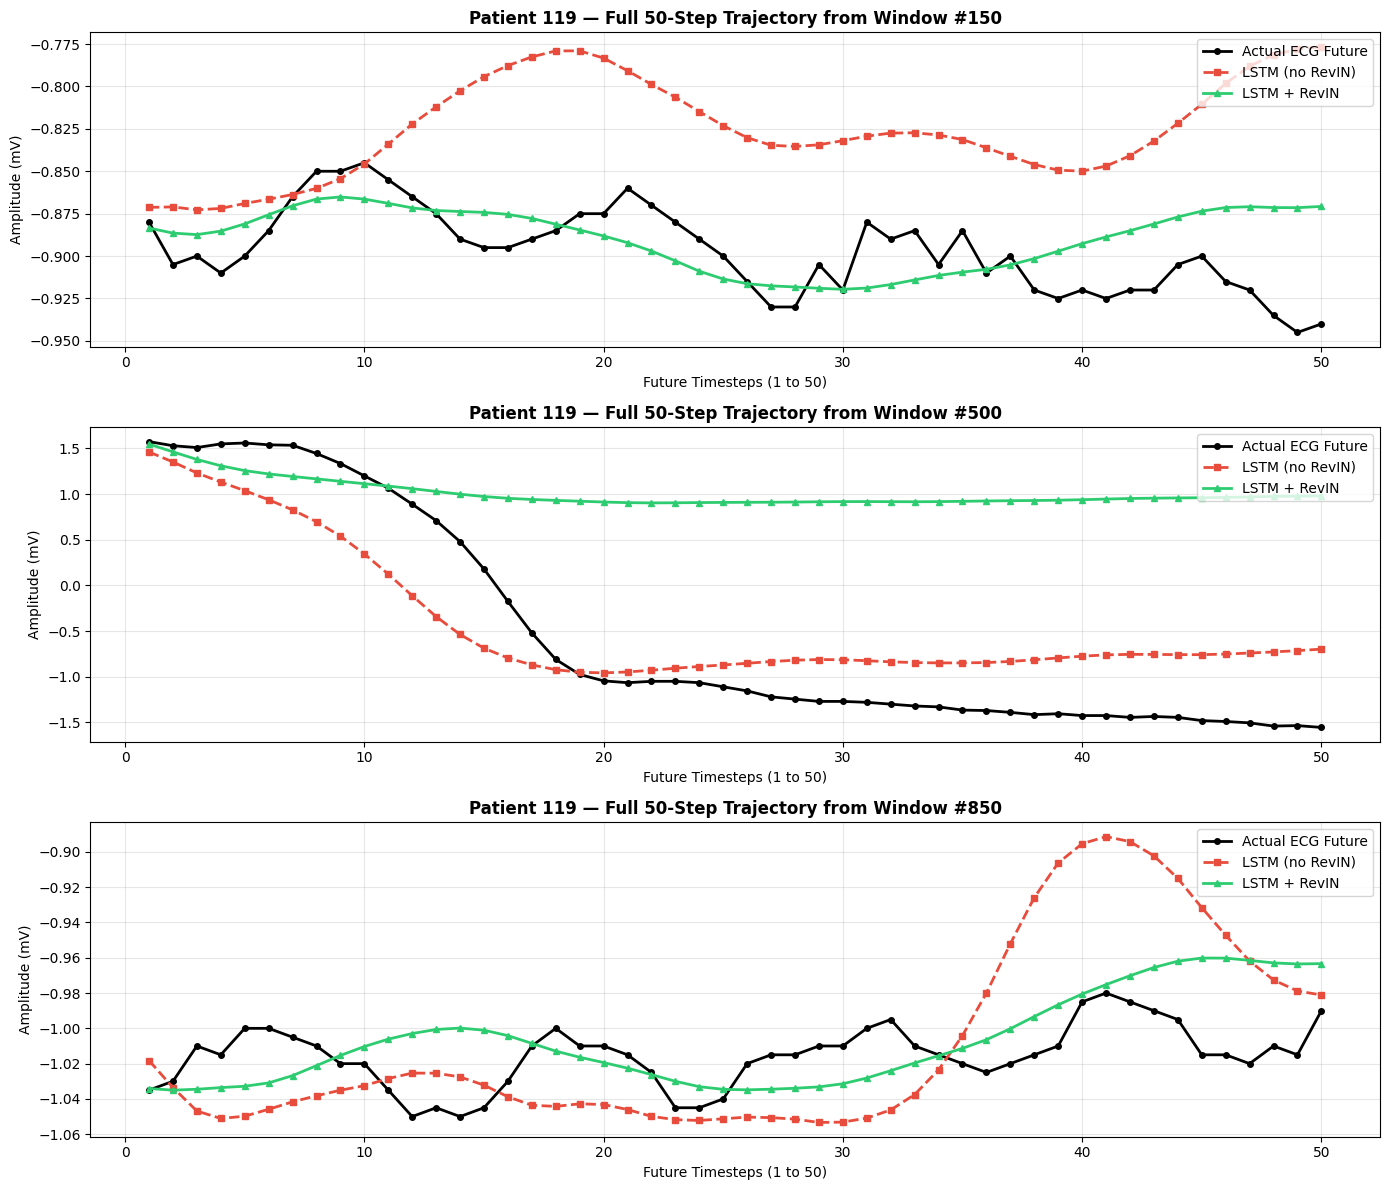

In [52]:
import matplotlib.pyplot as plt

# Configuration
TEST_PT = '119' 
WINDOWS_TO_PLOT = [150, 500, 850] 
HORIZONS = [10, 20, 50]

# Loop through each prediction horizon
for H_EVAL in HORIZONS:
    # 1. Create a NEW figure and axes for each horizon evaluation
    fig, axes = plt.subplots(len(WINDOWS_TO_PLOT), 1, figsize=(14, 4 * len(WINDOWS_TO_PLOT)))
    
    # Handle single subplot edge case if WINDOWS_TO_PLOT has only 1 element
    if len(WINDOWS_TO_PLOT) == 1:
        axes = [axes]

    # Extract predictions for this specific H_EVAL
    preds_nr = inter_results[H_EVAL]['LSTM (no RevIN)']['predictions'][TEST_PT]
    preds_re = inter_results[H_EVAL]['LSTM + RevIN']['predictions'][TEST_PT]

    x_steps = range(1, H_EVAL + 1) # X-axis matches current horizon

    for idx, window_idx in enumerate(WINDOWS_TO_PLOT):
        ax = axes[idx]
        
        # 2. Slice trajectory array to match x_steps length (:H_EVAL)
        y_true_traj = preds_nr['y_true'][window_idx, :H_EVAL] 
        y_nr_traj   = preds_nr['y_pred'][window_idx, :H_EVAL]
        y_re_traj   = preds_re['y_pred'][window_idx, :H_EVAL]

        # Plot trajectories
        ax.plot(x_steps, y_true_traj, label='Actual ECG Future', color='black', marker='o', markersize=4, linewidth=2)
        ax.plot(x_steps, y_nr_traj, label='LSTM (no RevIN)', color='#e74c3c', marker='s', markersize=4, linestyle='--', linewidth=2)
        ax.plot(x_steps, y_re_traj, label='LSTM + RevIN', color='#2ecc71', marker='^', markersize=4, linewidth=2)

        ax.set_title(f"Patient {TEST_PT} — Full {H_EVAL}-Step Trajectory from Window #{window_idx}", fontsize=12, fontweight='bold')
        ax.set_xlabel(f'Future Timesteps (1 to {H_EVAL})')
        ax.set_ylabel('Amplitude (mV)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()  # Displays distinct 3-row figures for H=10, H=20, and H=50